# Análisis de Geometría — Termalización AmBe
Cómo afectan las dimensiones de la parafina (Ancho × Alto × Espesor) a la termalización.  
Lee directamente los archivos `AmBe_*.root` de `build/` — no requiere CSV.

In [1]:
import os, re, glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import uproot

plt.rcParams.update({'figure.dpi': 130, 'font.size': 11,
                     'axes.grid': True, 'grid.alpha': 0.3,
                     'axes.spines.top': False, 'axes.spines.right': False})

BUILD_DIR = os.path.abspath('../build')
BEAM_ON   = 100000
ACTIVITY  = 2.98

_pat = re.compile(r'AmBe_(\d+)x(\d+)x(\d+)cm_d(\d+)cm\.root')

rows = []
for fpath in sorted(glob.glob(os.path.join(BUILD_DIR, 'AmBe_*.root'))):
    m = _pat.match(os.path.basename(fpath))
    if not m:
        continue
    ancho, alto, esp, dist = map(int, m.groups())
    try:
        with uproot.open(fpath) as f:
            arr = f['PhaseSpace'].arrays(['Particle', 'KinE_eV'], library='np')
        part = arr['Particle']
        ene  = arr['KinE_eV']
        n_n  = int((part == 'neutron').sum())
        n_g  = int((part == 'gamma').sum())
        n_e  = int((part == 'e-').sum())
        en_n = ene[part == 'neutron']
        n_th = int((en_n <= 0.025).sum())
        n_ep = int(((en_n > 0.025) & (en_n < 0.5e6)).sum())
        n_fa = int((en_n >= 0.5e6).sum())
        # Fracción sobre neutrones SIMULADOS (BEAM_ON), no sobre los detectados
        frac = n_th / BEAM_ON * 100
        tasa = n_n / BEAM_ON * ACTIVITY * 2.2e6
        rows.append({
            'Ancho_cm':         float(ancho),
            'Alto_cm':          float(alto),
            'Espesor_cm':       float(esp),
            'Distancia_cm':     int(dist),
            'BeamOn':           BEAM_ON,
            'Actividad_Ci':     ACTIVITY,
            'Neutrones':        n_n,
            'Gammas':           n_g,
            'Electrones':       n_e,
            'N_termicos':       n_th,
            'N_epitermicos':    n_ep,
            'N_rapidos':        n_fa,
            'Frac_termica_%':   round(frac, 4),
            'Efic_deteccion_%': round(n_n / BEAM_ON * 100, 4),
            'Tasa_n_det_ps':    round(tasa, 2),
            'Tasa_term_ps':     round(tasa * frac / 100, 2),
            'Area_frontal_cm2': float(ancho * alto),
            'Cara_cuadrada':    ancho == alto,
        })
    except Exception as e:
        print(f'SKIP {os.path.basename(fpath)}: {e}')

df         = pd.DataFrame(rows)
distancias = sorted(df['Distancia_cm'].unique())
espesores  = sorted(df['Espesor_cm'].unique())

_n      = len(distancias)
colores = dict(zip(distancias, plt.cm.tab10(np.linspace(0, 0.65, max(_n, 2)))))
markers = dict(zip(distancias, ['o', 's', '^', 'D', 'v'][:_n]))

print(f'Archivos leídos : {len(rows)}')
print(f'Distancias (cm) : {distancias}')
print(f'Espesores  (cm) : {espesores}')
print(f'Anchos     (cm) : {sorted(df.Ancho_cm.unique())}')
print(f'Altos      (cm) : {sorted(df.Alto_cm.unique())}')
df.head(3)

Archivos leídos : 8000
Distancias (cm) : [np.int64(0)]
Espesores  (cm) : [np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(4.0), np.float64(5.0), np.float64(6.0), np.float64(7.0), np.float64(8.0), np.float64(9.0), np.float64(10.0), np.float64(11.0), np.float64(12.0), np.float64(13.0), np.float64(14.0), np.float64(15.0), np.float64(16.0), np.float64(17.0), np.float64(18.0), np.float64(19.0), np.float64(20.0)]
Anchos     (cm) : [np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(4.0), np.float64(5.0), np.float64(6.0), np.float64(7.0), np.float64(8.0), np.float64(9.0), np.float64(10.0), np.float64(11.0), np.float64(12.0), np.float64(13.0), np.float64(14.0), np.float64(15.0), np.float64(16.0), np.float64(17.0), np.float64(18.0), np.float64(19.0), np.float64(20.0)]
Altos      (cm) : [np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(4.0), np.float64(5.0), np.float64(6.0), np.float64(7.0), np.float64(8.0), np.float64(9.0), np.float64(10.0), np.float64(11.0

,Ancho_cm,Alto_cm,Espesor_cm,Distancia_cm,BeamOn,Actividad_Ci,Neutrones,Gammas,Electrones,N_termicos,N_epitermicos,N_rapidos,Frac_termica_%,Efic_deteccion_%,Tasa_n_det_ps,Tasa_term_ps,Area_frontal_cm2,Cara_cuadrada
0,10.0,10.0,10.0,0,100000,2.98,277,263,10,19,97,161,0.019,0.277,18160.12,3.45,100.0,True
1,10.0,10.0,11.0,0,100000,2.98,233,218,6,19,96,118,0.019,0.233,15275.48,2.90,100.0,True
2,10.0,10.0,12.0,0,100000,2.98,178,171,6,19,64,95,0.019,0.178,11669.68,2.22,100.0,True


In [2]:
df.to_csv('Termalizacion.csv')

## 1. % Termalización vs dimensiones de la parafina
Para cada punto se toma el **máximo** sobre las demás dimensiones libres.  
Una curva por distancia fuente–parafina.

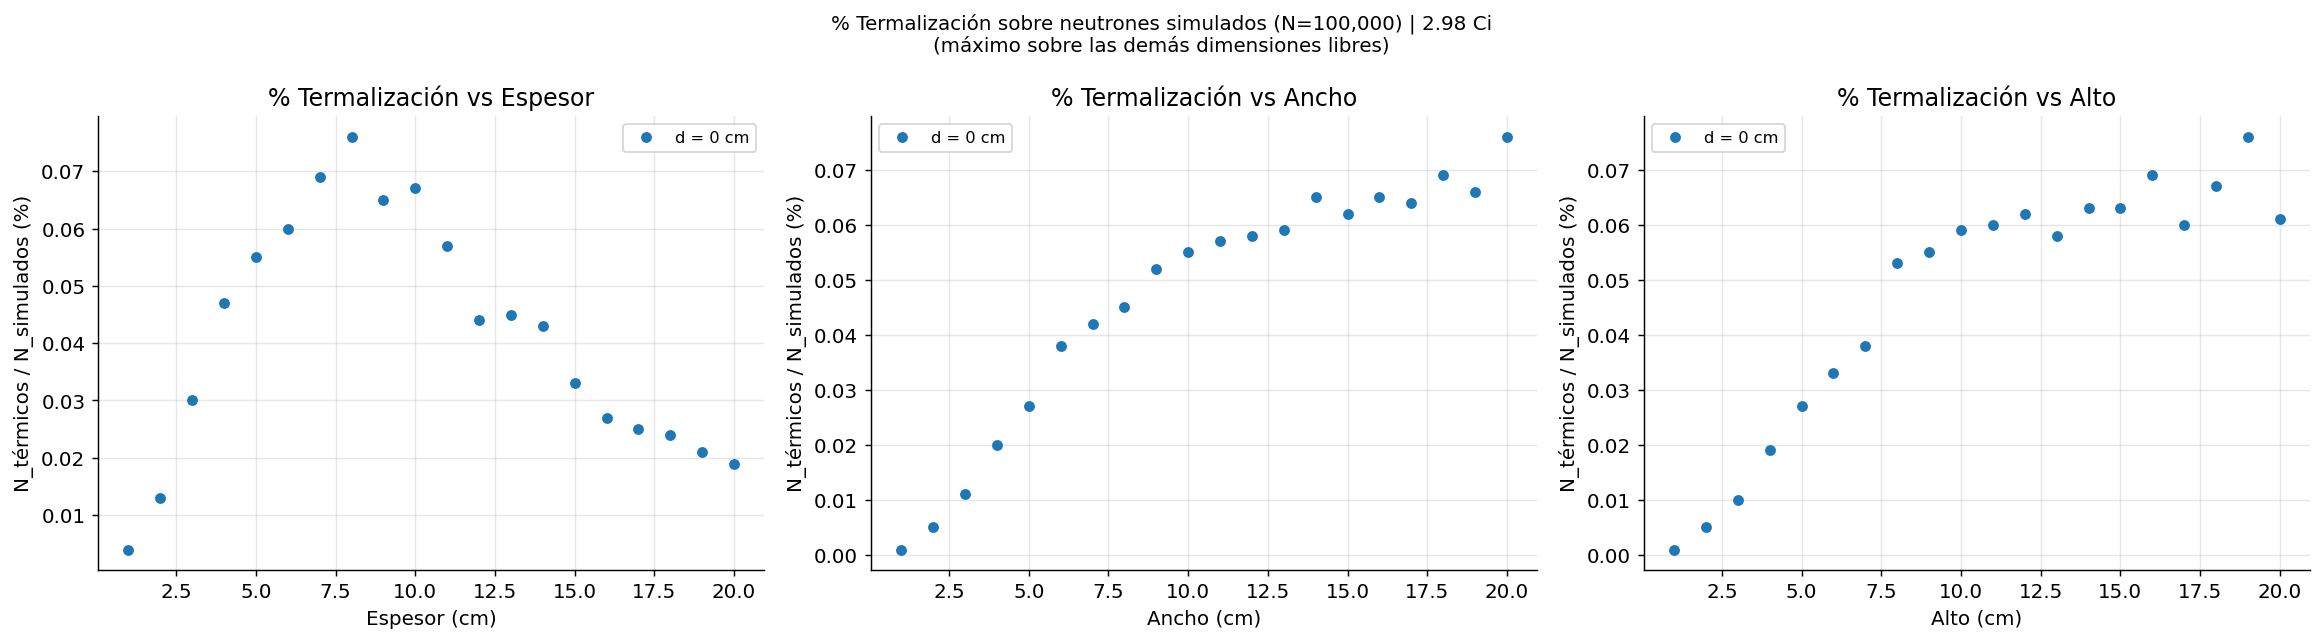

In [3]:
df_esp = df.groupby(['Espesor_cm', 'Distancia_cm'])['Frac_termica_%'].max().reset_index()
df_anc = df.groupby(['Ancho_cm',   'Distancia_cm'])['Frac_termica_%'].max().reset_index()
df_alt = df.groupby(['Alto_cm',    'Distancia_cm'])['Frac_termica_%'].max().reset_index()

specs = [
    (df_esp, 'Espesor_cm', 'Espesor (cm)', '% Termalización vs Espesor'),
    (df_anc, 'Ancho_cm',   'Ancho (cm)',   '% Termalización vs Ancho'),
    (df_alt, 'Alto_cm',    'Alto (cm)',    '% Termalización vs Alto'),
]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (data, xcol, xlabel, title) in zip(axes, specs):
    for dist in distancias:
        sub = data[data.Distancia_cm == dist].sort_values(xcol)
        ax.plot(sub[xcol], sub['Frac_termica_%'],
                marker=markers[dist], color=colores[dist],
                lw=0, ms=5, label=f'd = {int(dist)} cm')
    ax.set_xlabel(xlabel)
    ax.set_ylabel('N_térmicos / N_simulados (%)')
    ax.set_title(title)
    ax.legend(fontsize=9)

plt.suptitle(
    f'% Termalización sobre neutrones simulados (N={BEAM_ON:,}) | {ACTIVITY} Ci'
    f'\n(máximo sobre las demás dimensiones libres)',
    fontsize=11)
plt.tight_layout()
plt.show()

## 2. Mapa de calor — Espesor vs Lado (caras cuadradas, Ancho = Alto)
Permite identificar la zona de mayor termalización. Un panel por distancia.

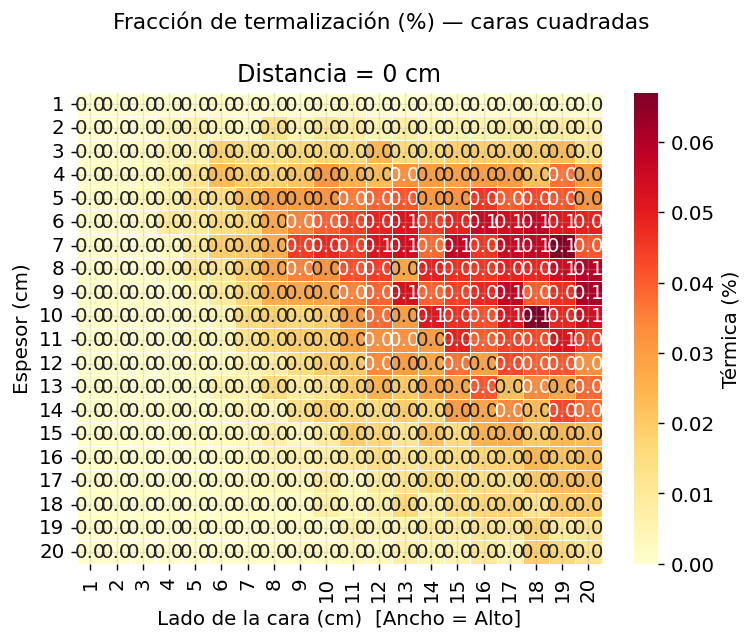

In [4]:
sq   = df[df['Cara_cuadrada']].copy()
vmax = sq['Frac_termica_%'].max() or 1.0

fig, axes = plt.subplots(1, len(distancias), figsize=(6 * len(distancias), 5))
if len(distancias) == 1:
    axes = [axes]

for ax, dist in zip(axes, distancias):
    sub   = sq[sq.Distancia_cm == dist]
    pivot = sub.pivot_table(values='Frac_termica_%',
                            index='Espesor_cm', columns='Ancho_cm')
    pivot.index   = [f'{v:.0f}' for v in pivot.index]
    pivot.columns = [f'{v:.0f}' for v in pivot.columns]
    sns.heatmap(pivot, ax=ax, annot=True, fmt='.1f', cmap='YlOrRd',
                linewidths=0.4, vmin=0, vmax=vmax,
                cbar_kws={'label': 'Térmica (%)'})
    ax.set_title(f'Distancia = {int(dist)} cm')
    ax.set_xlabel('Lado de la cara (cm)  [Ancho = Alto]')
    ax.set_ylabel('Espesor (cm)')

plt.suptitle('Fracción de termalización (%) — caras cuadradas', fontsize=12)
plt.tight_layout()
plt.show()

## 3. Eficiencia de detección de neutrones vs Espesor
Fracción de los neutrones simulados que llegan al detector.  
Panel izquierdo: máximo por espesor. Panel derecho: Ancho vs Alto en el espesor óptimo.

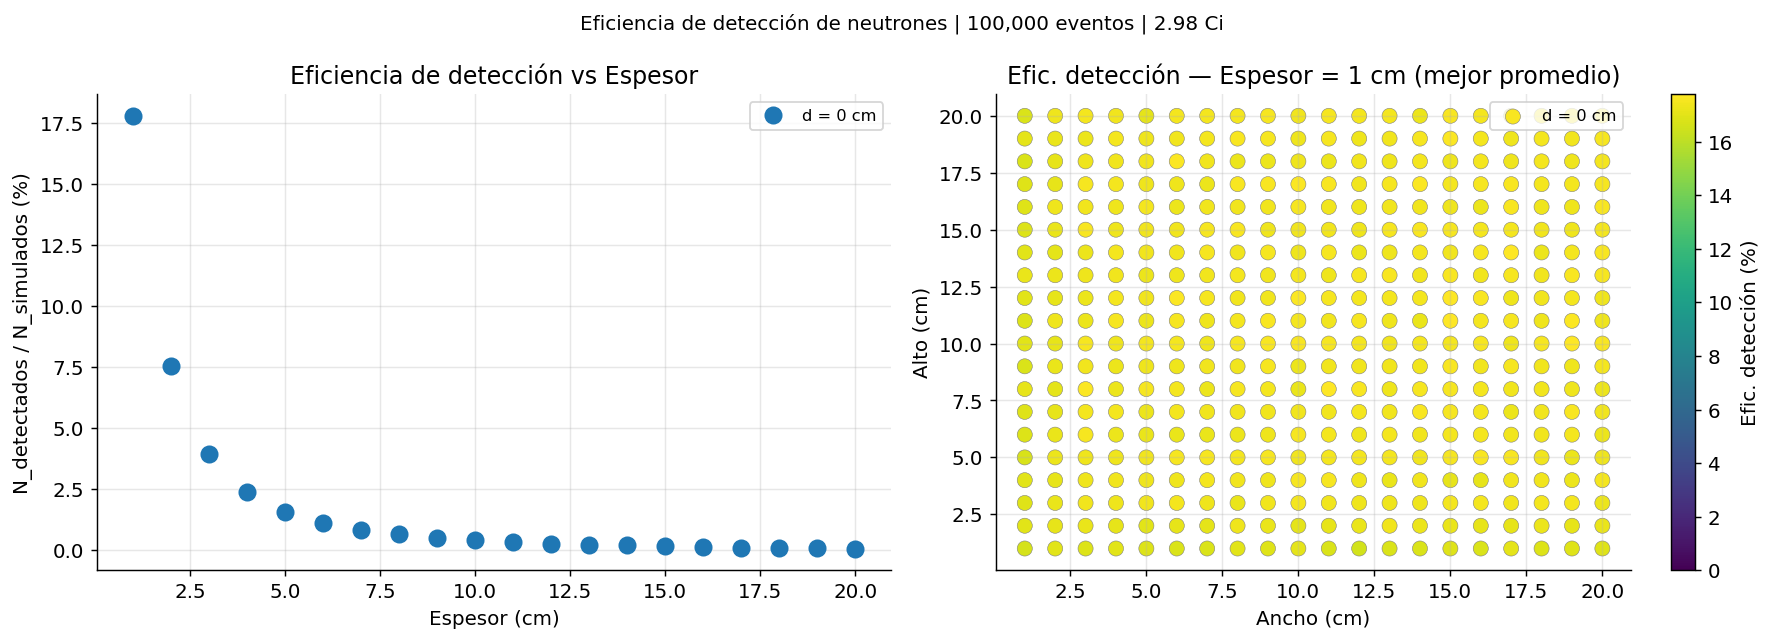

In [5]:
df_efic = df.groupby(['Espesor_cm', 'Distancia_cm'])['Efic_deteccion_%'].max().reset_index()
esp_best = df.groupby('Espesor_cm')['Efic_deteccion_%'].mean().idxmax()
sub_best = df[df.Espesor_cm == esp_best]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
for dist in distancias:
    sub = df_efic[df_efic.Distancia_cm == dist].sort_values('Espesor_cm')
    ax.plot(sub['Espesor_cm'], sub['Efic_deteccion_%'],
            marker=markers[dist], color=colores[dist],
            lw=0, ms=9, label=f'd = {int(dist)} cm')
ax.set_xlabel('Espesor (cm)')
ax.set_ylabel('N_detectados / N_simulados (%)')
ax.set_title('Eficiencia de detección vs Espesor')
ax.legend(fontsize=9)

ax = axes[1]
sc = None
for dist in distancias:
    s = sub_best[sub_best.Distancia_cm == dist]
    sc = ax.scatter(s['Ancho_cm'], s['Alto_cm'],
                    c=s['Efic_deteccion_%'], cmap='viridis',
                    s=70, marker=markers[dist], edgecolors='grey', linewidths=0.3,
                    vmin=0, vmax=sub_best['Efic_deteccion_%'].max(),
                    label=f'd = {int(dist)} cm')
if sc is not None:
    plt.colorbar(sc, ax=ax, label='Efic. detección (%)')
ax.set_xlabel('Ancho (cm)')
ax.set_ylabel('Alto (cm)')
ax.set_title(f'Efic. detección — Espesor = {esp_best:.0f} cm (mejor promedio)')
ax.legend(fontsize=9)

plt.suptitle(f'Eficiencia de detección de neutrones | {BEAM_ON:,} eventos | {ACTIVITY} Ci',
             fontsize=11)
plt.tight_layout()
plt.show()

## 4. Tabla resumen — Mejores geometrías por distancia
Dos criterios: mayor fracción de termalización (%) y mayor número absoluto de neutrones térmicos.

In [6]:
resumen = []
for dist in distancias:
    sub = df[df.Distancia_cm == dist]

    r_frac = sub.loc[sub['Frac_termica_%'].idxmax()]
    r_abs  = sub.loc[sub['N_termicos'].idxmax()]

    resumen.append({
        'Dist (cm)':           int(dist),
        'Geom. max %term':     f"{int(r_frac.Ancho_cm)}×{int(r_frac.Alto_cm)}×{int(r_frac.Espesor_cm)} cm",
        'Frac_term_%':         round(r_frac['Frac_termica_%'], 2),
        'N_termicos (max %)':  r_frac['N_termicos'],
        'Geom. max N_term':    f"{int(r_abs.Ancho_cm)}×{int(r_abs.Alto_cm)}×{int(r_abs.Espesor_cm)} cm",
        'N_termicos (max abs)': r_abs['N_termicos'],
        'Frac_term (max abs)%': round(r_abs['Frac_termica_%'], 2),
        'Efic_%':              round(r_abs['Efic_deteccion_%'], 3),
    })

df_res = pd.DataFrame(resumen).set_index('Dist (cm)')
print('· max %term  → geometría con mayor fracción de termalización')
print('· max N_term → geometría con más neutrones térmicos en detector\n')
display(df_res)

· max %term  → geometría con mayor fracción de termalización
· max N_term → geometría con más neutrones térmicos en detector



,Geom. max %term,Frac_term_%,N_termicos (max %),Geom. max N_term,N_termicos (max abs),Frac_term (max abs)%,Efic_%
Dist (cm),,,,,,,
0,20×19×8 cm,0.08,76,20×19×8 cm,76,0.08,0.582


## 5. Espectro de energías — Geometría óptima por distancia
Para cada distancia se carga el ROOT de la geometría con mayor fracción de termalización.

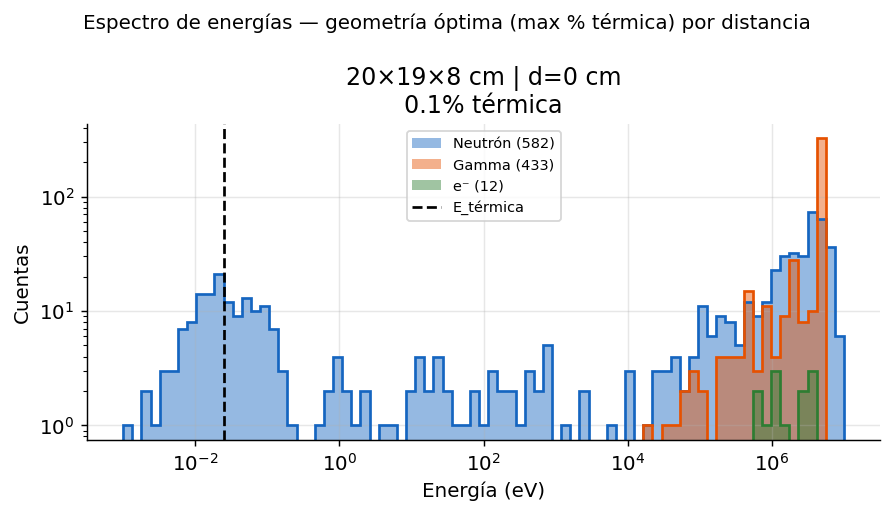

In [8]:
part_cfg = {
    'neutron': ('#1565C0', 'Neutrón'),
    'gamma':   ('#E65100', 'Gamma'),
    'e-':      ('#2E7D32', 'e⁻'),
}
bins = np.logspace(-3, 7, 80)

fig, axes = plt.subplots(1, len(distancias), figsize=(7 * len(distancias), 4), sharey=False)
if len(distancias) == 1:
    axes = [axes]

for ax, dist in zip(axes, distancias):
    sub = df[df.Distancia_cm == dist]
    if sub.empty:
        continue
    row   = sub.loc[sub['Frac_termica_%'].idxmax()]
    ancho = int(row.Ancho_cm)
    alto  = int(row.Alto_cm)
    esp   = int(row.Espesor_cm)
    fpath = os.path.join(BUILD_DIR, f'AmBe_{ancho}x{alto}x{esp}cm_d{int(dist)}cm.root')
    if not os.path.exists(fpath):
        ax.text(0.5, 0.5, 'ROOT no encontrado', ha='center', va='center',
                transform=ax.transAxes, color='red')
        continue
    with uproot.open(fpath) as f:
        arr = f['PhaseSpace'].arrays(['Particle', 'KinE_eV'], library='np')
    for pname, (col, lbl) in part_cfg.items():
        mask = arr['Particle'] == pname
        if not mask.any():
            continue
        ax.hist(arr['KinE_eV'][mask], bins=bins, histtype='stepfilled',
                alpha=0.45, color=col, label=f'{lbl} ({mask.sum()})')
        ax.hist(arr['KinE_eV'][mask], bins=bins, histtype='step', color=col, lw=1.5)
    ax.axvline(0.025, color='k', ls='--', lw=1.5, label='E_térmica')
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlabel('Energía (eV)')
    ax.set_ylabel('Cuentas')
    ax.set_title(f'{ancho}×{alto}×{esp} cm | d={int(dist)} cm\n'
                 f'{row["Frac_termica_%"]:.1f}% térmica')
    ax.legend(fontsize=8)

plt.suptitle('Espectro de energías — geometría óptima (max % térmica) por distancia', fontsize=11)
plt.tight_layout()
plt.show()